# ECG Heartbeat Classification Case Study (Anti-Overfitting & Regularization)

This notebook imports the preprocessed dataset from `classification_preprocessing.ipynb`, splits the data into training and testing sets, and trains five classification algorithms with strict hyperparameter regularization to prevent model overfitting:

1. **Logistic Regression** (Baseline classifier; L2 regularization tuning over $C$; odds ratio analysis)
2. **K-Nearest Neighbors (KNN)** (Hyperparameter tuning enforcing $k \ge 3$; distance metrics & feature scaling analysis)
3. **Gaussian Naive Bayes** (`var_smoothing` tuning; check of conditional independence assumption)
4. **Decision Tree Classifier** (Constraining `max_depth`, `min_samples_split`, and `min_samples_leaf`; tree visualization & feature importances)
5. **Support Vector Machine (SVC)** (Tuning regularization parameter $C$ and `kernel`; feature scaling analysis)

---


Numpy array representaion for X_signals
[[-0.26  -0.265 -0.27  ... -0.295 -0.29  -0.305]
 [-0.315 -0.305 -0.315 ... -0.35  -0.34  -0.335]
 [-0.32  -0.325 -0.305 ... -0.3   -0.31  -0.33 ]
 ...
 [-0.215 -0.215 -0.225 ... -0.25  -0.265 -0.28 ]
 [-0.25  -0.23  -0.22  ... -0.225 -0.24  -0.24 ]
 [-0.25  -0.245 -0.225 ... -0.19  -0.185 -0.18 ]]
Numpy array representaion for y_regression
[0.81111111 0.78888889 0.79166667 ... 0.7        0.67777778 0.65555556]
Numpy array representaion for y_classification
['N' 'N' 'N' ... 'N' 'N' 'N']
X_signals
------------
Shape of the X_signals for training : (109423, 300)
Datatypes of the X_signals for training : float64
Missing value counts of the X_signals for training : 0

y_regression
----------------
Shape of the y_regression for training : (109423,)
Datatypes of the y_regression for training : float64
Missing value counts of the y_regression for training : 0


Regression Target Summary Statistics:
count    109423.000000
mean          0.777378
std      

/var/folders/ll/q61vfn714894jcrfq0_d1sqw0000gn/T/ipykernel_85687/1376864256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='target_classification_class', palette='Set2', ax=axes[0])


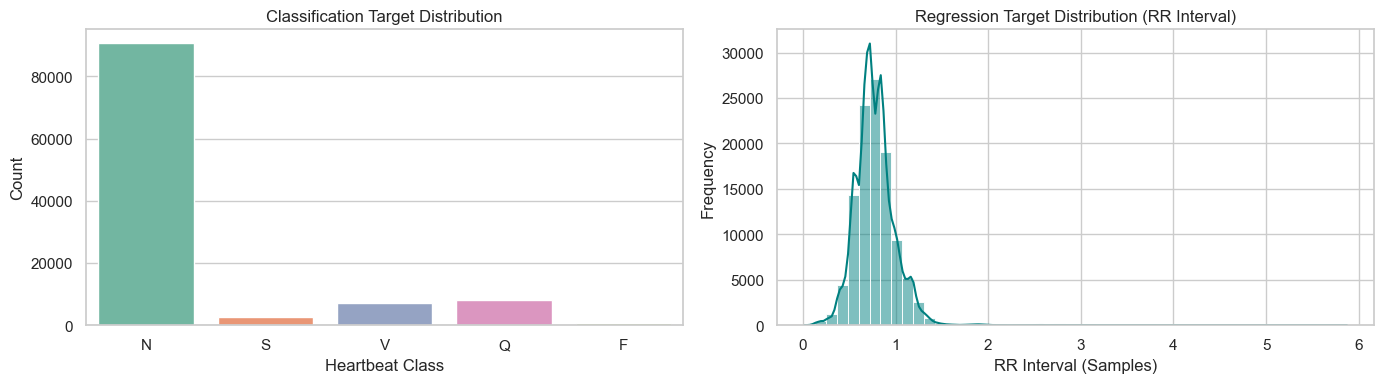

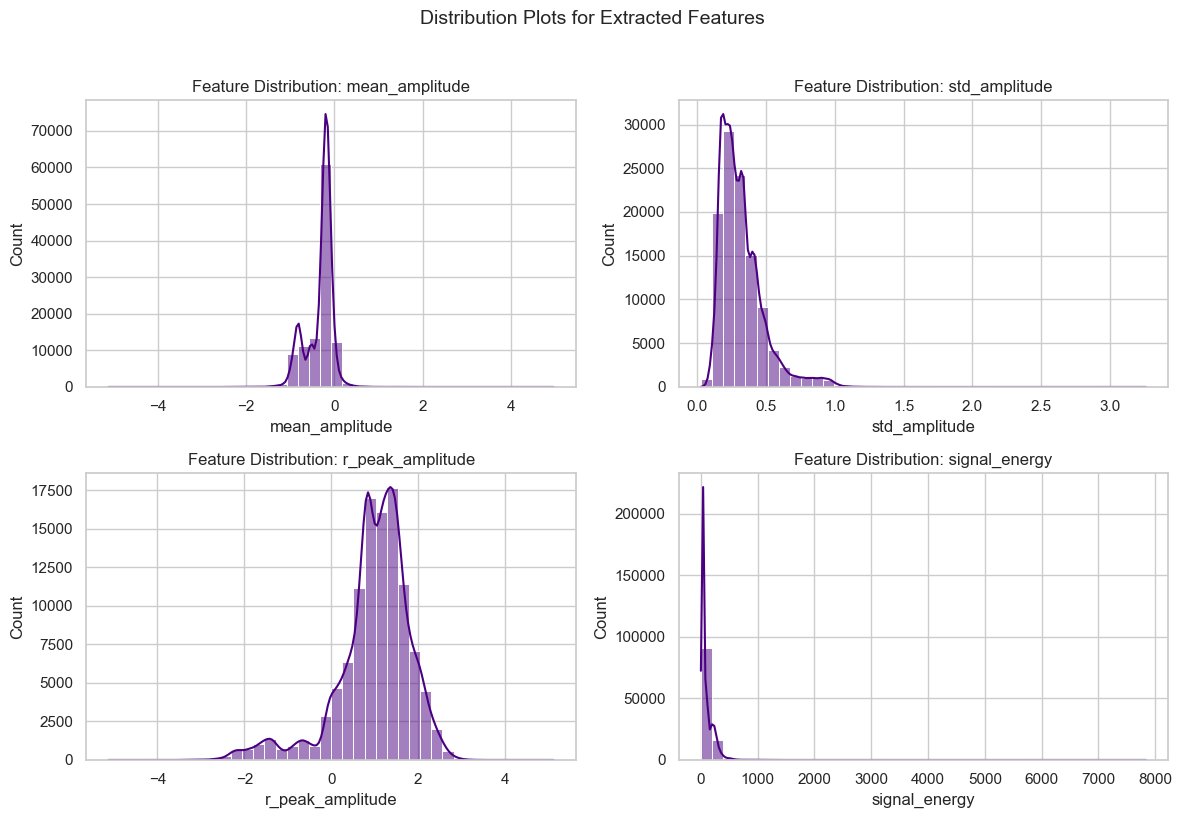

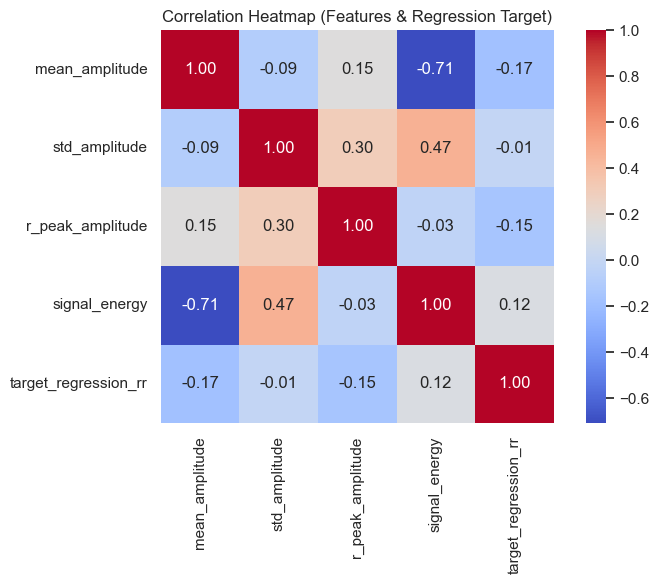

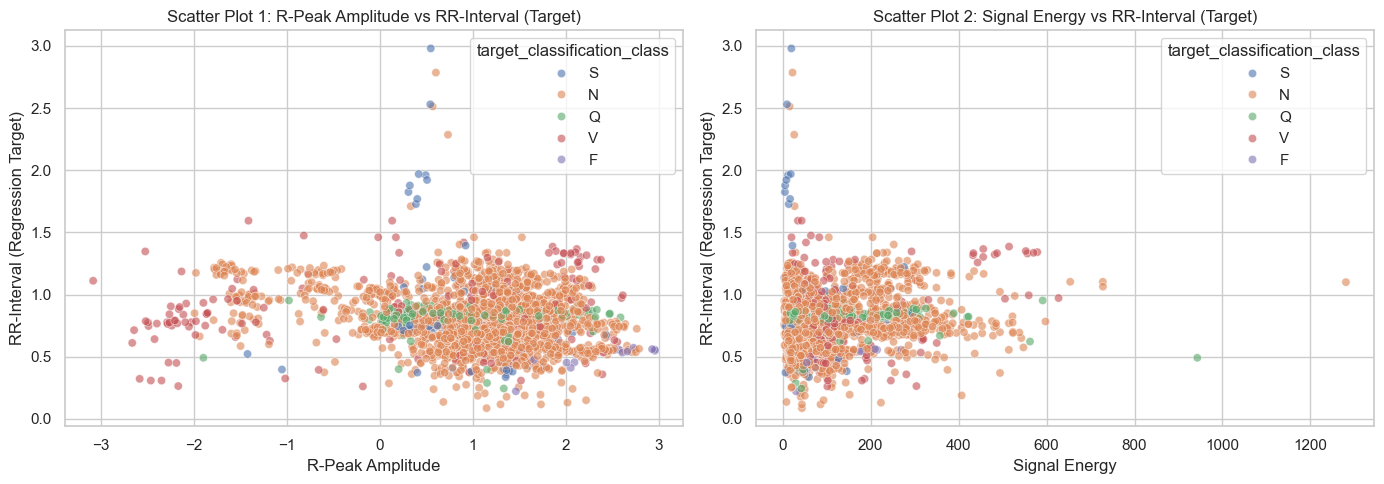

Original dataset shape: (109423, 6)
Missing values before cleaning:
mean_amplitude                 0
std_amplitude                  0
r_peak_amplitude               0
signal_energy                  0
target_regression_rr           0
target_classification_class    0
dtype: int64

Total missing values: 0

No missing or non-finite values found.

Number of duplicate rows: 0
No duplicate rows found.

Outlier Summary:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,mean_amplitude,-0.444125,-0.136667,0.307458,-0.905313,0.324521,5803,5.30
1,std_amplitude,0.206439,0.392853,0.186414,-0.073181,0.672474,4473,4.09
2,r_peak_amplitude,0.670000,1.505000,0.835000,-0.582500,2.757500,6839,6.25
3,signal_energy,26.938850,129.601362,102.662512,-127.054919,283.595131,6614,6.04


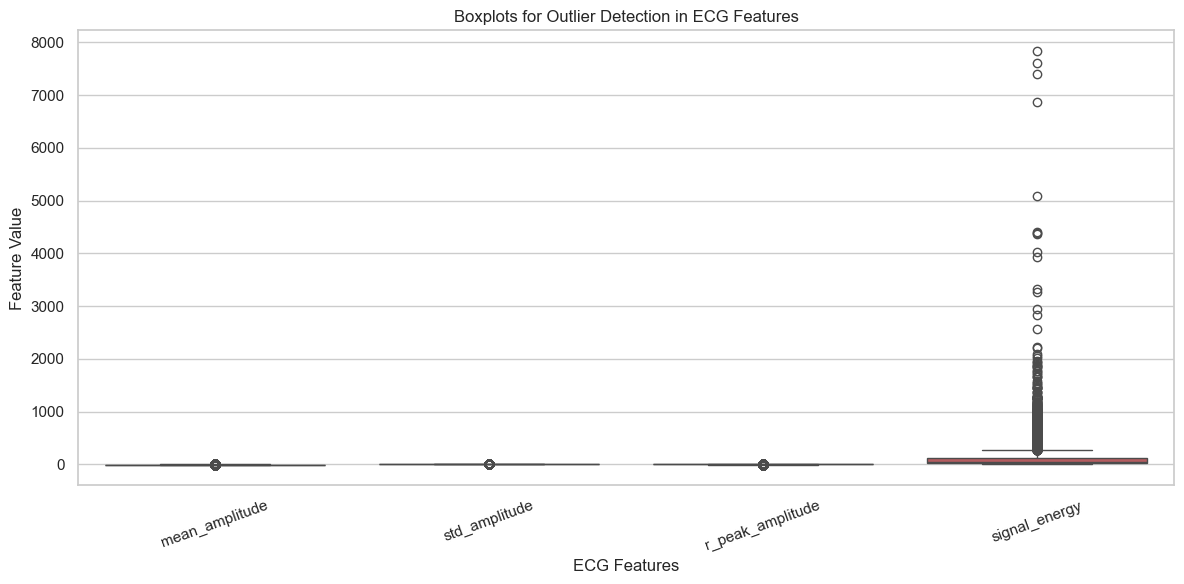


Final dataset shape: (109423, 6)

Missing values after cleaning:
mean_amplitude                 0
std_amplitude                  0
r_peak_amplitude               0
signal_energy                  0
target_regression_rr           0
target_classification_class    0
dtype: int64

Duplicate rows after cleaning:
7

Final dataset preview:


,mean_amplitude,std_amplitude,r_peak_amplitude,signal_energy,target_regression_rr,target_classification_class
0,-0.312100,0.184448,0.940,39.428250,0.811111,N
1,-0.331017,0.167815,0.885,41.320125,0.788889,N
2,-0.334250,0.159483,0.810,41.147325,0.791667,N
3,-0.335783,0.150804,0.820,40.647725,0.788889,N
4,-0.326067,0.160459,0.885,39.619950,0.816667,N


Engineered Features Summary Statistics:


,r_peak_to_std_ratio,peak_to_peak_amplitude,zero_crossing_rate
count,109423.000000,109423.000000,109423.000000
mean,3.354837,2.123567,0.013811
std,2.224168,0.859711,0.012605
min,-7.835581,0.135000,0.000000
25%,2.597231,1.455000,0.006667
50%,3.919389,1.950000,0.010000
75%,4.826407,2.650000,0.016667
max,16.723154,8.825000,0.213333


Updated Dataset Preview with Engineered Features:


,mean_amplitude,std_amplitude,r_peak_amplitude,signal_energy,target_regression_rr,target_classification_class,r_peak_to_std_ratio,peak_to_peak_amplitude,zero_crossing_rate
0,-0.312100,0.184448,0.940,39.428250,0.811111,N,5.096285,1.475,0.006667
1,-0.331017,0.167815,0.885,41.320125,0.788889,N,5.273679,1.530,0.006667
2,-0.334250,0.159483,0.810,41.147325,0.791667,N,5.078925,1.505,0.006667
3,-0.335783,0.150804,0.820,40.647725,0.788889,N,5.437506,1.385,0.006667
4,-0.326067,0.160459,0.885,39.619950,0.816667,N,5.515434,1.430,0.006667


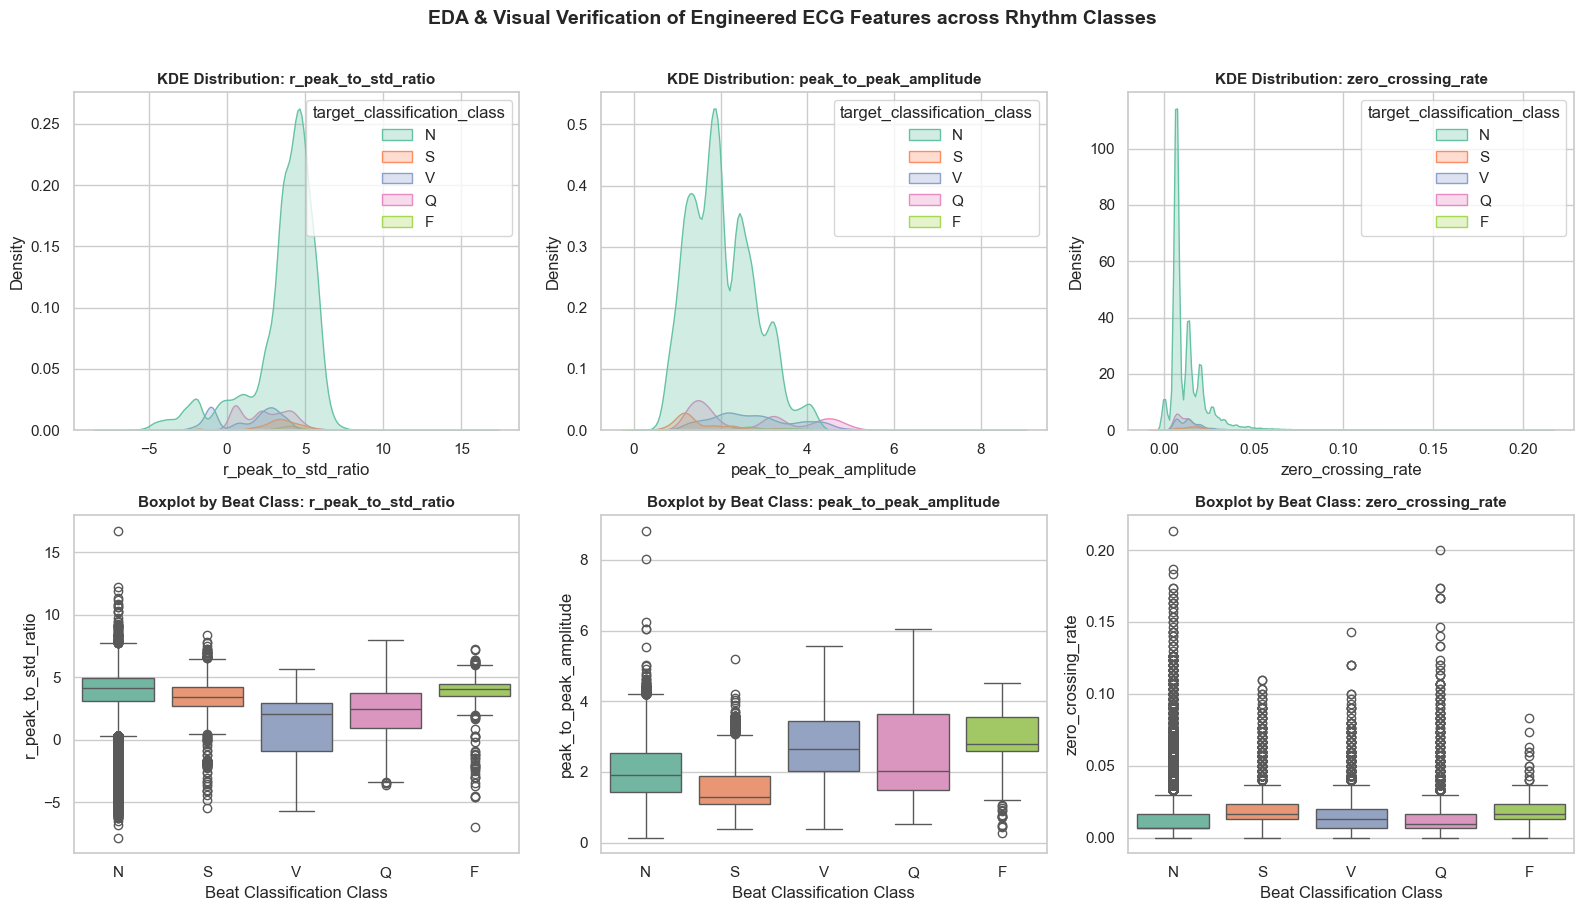

Classification Target Encoding Mapping:
  Class "F" -> Code 0 (Count: 802)
  Class "N" -> Code 1 (Count: 90571)
  Class "Q" -> Code 2 (Count: 8036)
  Class "S" -> Code 3 (Count: 2779)
  Class "V" -> Code 4 (Count: 7235)
Dataset Split Completed Successfully (80:20 Ratio):
  Training Features (X_train) Shape : (87538, 7)
  Testing Features  (X_test)  Shape : (21885, 7)

Stratified Class Distribution Audit:


,Train Ratio (%),Test Ratio (%)
target_classification_encoded,,
N,82.77,82.77
Q,7.34,7.34
V,6.61,6.61
S,2.54,2.54
F,0.73,0.73


StandardScaler Scaling Verification:
  X_train_scaled Mean (should be ~0) : [-0. -0. -0.  0.  0.  0.  0.]
  X_train_scaled Std  (should be  1) : [1. 1. 1. 1. 1. 1. 1.]

Scaled Training Features Preview (First 5 Rows):


,mean_amplitude,std_amplitude,r_peak_amplitude,signal_energy,r_peak_to_std_ratio,peak_to_peak_amplitude,zero_crossing_rate
0,0.389323,-0.621801,-0.439971,-0.717055,-0.088783,-0.832965,-0.038651
1,0.266790,2.585256,-0.768128,1.002824,-1.189869,2.247028,0.490551
2,0.770048,-0.795899,0.034808,-0.869051,0.833897,-0.239091,0.225950
3,0.630656,2.585256,-1.145159,0.707133,-1.371007,1.525063,-0.303252
4,0.400884,-0.546850,0.523552,-0.704656,1.156299,-0.367181,-0.567854


FINAL PREPROCESSING AUDIT & ARTIFACT SUMMARY
1. Total Cleaned Observations : 109423
2. Number of Feature Columns  : 7 -> ['mean_amplitude', 'std_amplitude', 'r_peak_amplitude', 'signal_energy', 'r_peak_to_std_ratio', 'peak_to_peak_amplitude', 'zero_crossing_rate']
3. Target Classification      : Multi-class (5 classes)
4. Target Regression          : Continuous (RR Interval)
5. X_train_scaled shape       : (87538, 7)
6. X_test_scaled shape        : (21885, 7)
7. y_class_train shape        : (87538,)
8. y_class_test shape         : (21885,)
9. y_reg_train shape          : (87538,)
10. y_reg_test shape          : (21885,)
Data Preprocessing, Feature Engineering, Encoding, Stratified Splitting, and Scaling pipeline completed cleanly without data leakage.

--- Successfully imported classifcation_preprocessing.ipynb ---
Loaded x_signals shape: (109423, 300)
Loaded y_classification shape: (109423,)
Loaded df_eda shape: (109423, 6)


In [1]:
# Import and execute preprocessing.ipynb to load preprocessed dataset
import os
import json

try:
    get_ipython().run_line_magic('run', 'classification_preprocessing.ipynb')
except Exception:
    try:
        get_ipython().run_line_magic('run', 'notebooks/classification_preprocessing.ipynb')
    except Exception:
        pref_path = 'notebooks/classification_preprocessing.ipynb' if os.path.exists('notebooks/classification_preprocessing.ipynb') else 'classification_preprocessing.ipynb'
        with open(pref_path) as pf:
            pnb = json.load(pf)
        for pcell in pnb['cells']:
            if pcell['cell_type'] == 'code':
                exec(''.join(pcell['source']), globals())

print("\n--- Successfully imported classifcation_preprocessing.ipynb ---")
print(f"Loaded x_signals shape: {x_signals.shape}")
print(f"Loaded y_classification shape: {y_classification.shape}")
print(f"Loaded df_eda shape: {df_eda.shape}")

## Setup Classification Imports and Feature Matrix

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc
)

# Extract tabular features from preprocessed df_eda
feature_cols = ['mean_amplitude', 'std_amplitude', 'r_peak_amplitude', 'signal_energy']

X_raw = df_eda[feature_cols].values
feature_names = feature_cols

# Encode class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_classification)
class_names = label_encoder.classes_

print("Selected Preprocessed Features:", feature_names)
print(f"Target Classes ({len(class_names)}): {list(enumerate(class_names))}")

Selected Preprocessed Features: ['mean_amplitude', 'std_amplitude', 'r_peak_amplitude', 'signal_energy']
Target Classes (5): [(0, 'F'), (1, 'N'), (2, 'Q'), (3, 'S'), (4, 'V')]


## Train-Test Split and Feature Scaling

In [3]:
# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Standardize features (Zero Mean, Unit Variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Set shape: {X_train_scaled.shape}")
print(f"Test Set shape:  {X_test_scaled.shape}")

Train Set shape: (87538, 4)
Test Set shape:  (21885, 4)


## Evaluation Helper Function

In [4]:
def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_prec = precision_score(y_true, y_pred, average='weighted')
    weighted_rec = recall_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr') if y_proba is not None else np.nan
    
    print(f"=== {name} Performance Metrics ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Weighted F1 Score:   {weighted_f1:.4f}")
    print(f"Macro F1 Score:      {macro_f1:.4f}")
    print(f"Weighted Precision:  {weighted_prec:.4f}")
    print(f"Weighted Recall:     {weighted_rec:.4f}")
    print(f"ROC-AUC (OvR):       {roc_auc:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    return {
        'Model': name,
        'Accuracy': acc,
        'Weighted F1': weighted_f1,
        'Macro F1': macro_f1,
        'Weighted Precision': weighted_prec,
        'Weighted Recall': weighted_rec,
        'ROC-AUC (OvR)': roc_auc
    }

---
## Algorithm 1: Logistic Regression

To prevent overfitting, we tune the inverse regularization parameter $C \in \{0.0001, 0.001, 0.01, 0.1, 1.0, 10.0\}$ using 5-fold cross-validation with an $L_2$ penalty:

$$P(Y = k \mid \mathbf{x}) = \frac{\exp(\beta_{k0} + \sum_{j=1}^p \beta_{kj} x_j)}{\sum_{m=1}^K \exp(\beta_{m0} + \sum_{j=1}^p \beta_{mj} x_j)}$$

Best Logistic Regression C: 0.1
Best 5-Fold CV Weighted F1: 0.8064


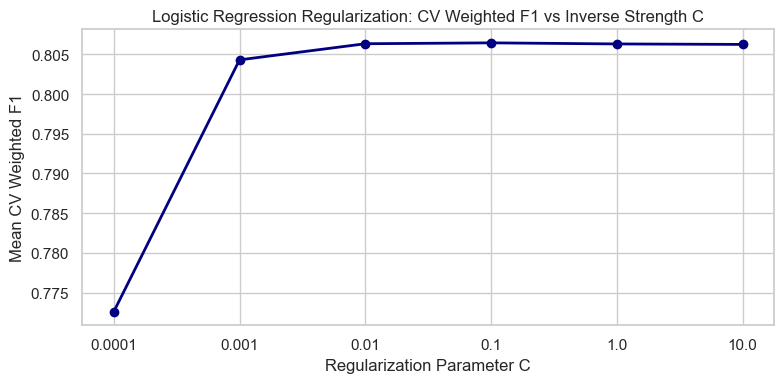

=== Logistic Regression Performance Metrics ===
Accuracy:            0.8480
Weighted F1 Score:   0.8065
Macro F1 Score:      0.2944
Weighted Precision:  0.7940
Weighted Recall:     0.8480
ROC-AUC (OvR):       0.8290

Classification Report:
              precision    recall  f1-score   support

           F       0.00      0.00      0.00       160
           N       0.88      0.99      0.93     18115
           Q       0.50      0.07      0.12      1607
           S       0.00      0.00      0.00       556
           V       0.43      0.42      0.42      1447

    accuracy                           0.85     21885
   macro avg       0.36      0.29      0.29     21885
weighted avg       0.79      0.85      0.81     21885



/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

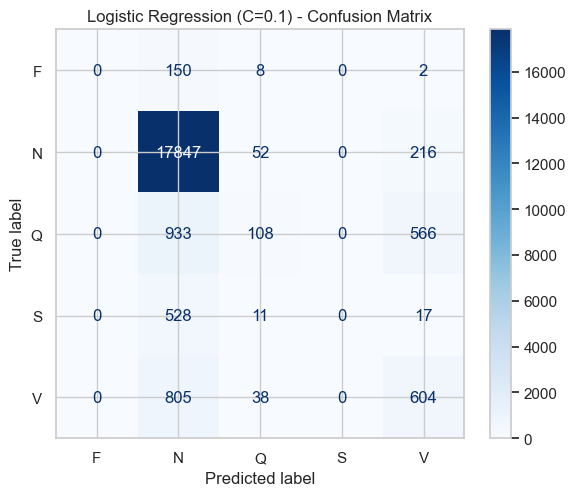

In [5]:
# Regularization Tuning for Logistic Regression
param_grid_lr = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0], 'penalty': ['l2']}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"Best Logistic Regression C: {grid_lr.best_params_['C']}")
print(f"Best 5-Fold CV Weighted F1: {grid_lr.best_score_:.4f}")

# Plot CV Weighted F1 vs C
results_lr = pd.DataFrame(grid_lr.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(results_lr['param_C'].astype(str), results_lr['mean_test_score'], marker='o', linewidth=2, color='navy')
plt.title("Logistic Regression Regularization: CV Weighted F1 vs Inverse Strength C")
plt.xlabel("Regularization Parameter C")
plt.ylabel("Mean CV Weighted F1")
plt.tight_layout()
plt.show()

# Best Model Evaluation
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)

metrics_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=class_names, cmap='Blues', ax=ax
)
plt.title(f'Logistic Regression (C={best_lr.C}) - Confusion Matrix')
plt.tight_layout()
plt.show()

Regularized Logistic Regression Coefficients & Odds Ratios:

                  Coef (F)  Coef (N)  Coef (Q)  Coef (S)  Coef (V)  \
mean_amplitude   -0.245317 -0.173149  0.217374  0.418932 -0.217838   
std_amplitude     0.794199 -1.049503  0.639119 -1.589472  1.205657   
r_peak_amplitude  1.185790  0.363235 -0.510568 -0.200695 -0.837763   
signal_energy    -0.967250  0.792632 -0.009507  0.535749 -0.351625   

                  OddsRatio (F)  OddsRatio (N)  OddsRatio (Q)  OddsRatio (S)  \
mean_amplitude         0.782456       0.841012       1.242808       1.520336   
std_amplitude          2.212667       0.350112       1.894810       0.204033   
r_peak_amplitude       3.273272       1.437974       0.600154       0.818162   
signal_energy          0.380127       2.209204       0.990538       1.708728   

                  OddsRatio (V)  
mean_amplitude         0.804255  
std_amplitude          3.338952  
r_peak_amplitude       0.432678  
signal_energy          0.703544  


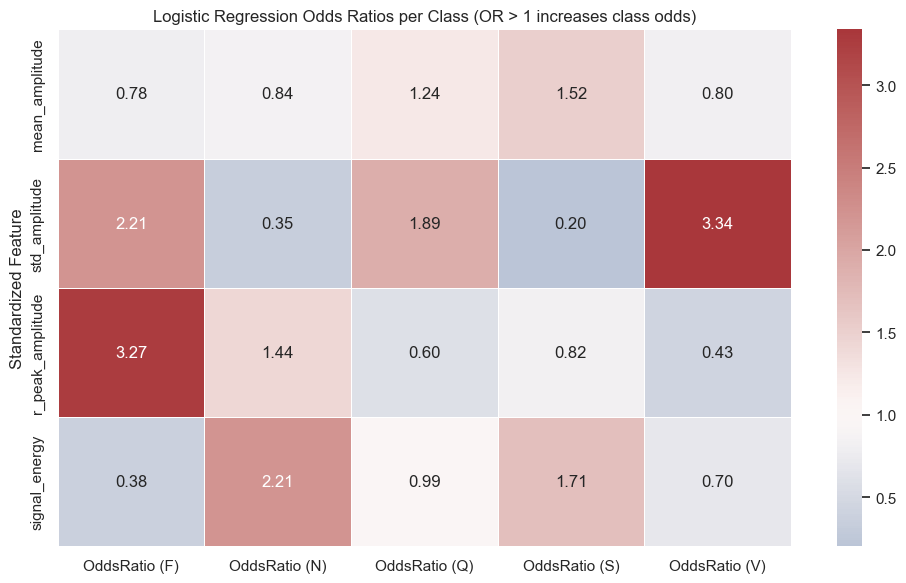

In [6]:
# Coefficients & Odds Ratios Analysis
coefficients = best_lr.coef_
odds_ratios = np.exp(coefficients)

df_coef = pd.DataFrame(coefficients.T, index=feature_names, columns=[f"Coef ({c})" for c in class_names])
df_odds = pd.DataFrame(odds_ratios.T, index=feature_names, columns=[f"OddsRatio ({c})" for c in class_names])

df_interpretation = pd.concat([df_coef, df_odds], axis=1)
print("Regularized Logistic Regression Coefficients & Odds Ratios:\n")
print(df_interpretation)

# Visualization of Odds Ratios
plt.figure(figsize=(10, 6))
sns.heatmap(df_odds, annot=True, fmt=".2f", cmap="vlag", center=1.0, linewidths=0.5)
plt.title("Logistic Regression Odds Ratios per Class (OR > 1 increases class odds)")
plt.ylabel("Standardized Feature")
plt.tight_layout()
plt.show()

---
## Algorithm 2: K-Nearest Neighbors (KNN - Enforcing $k \ge 3$)

To eliminate single-neighbor memorization ($k=1$ overfitting), we constrain the hyperparameter search space to odd values $k \in \{3, 5, 7, 9, 11, 15, 21, 25\}$:

$$D_p(\mathbf{x}_a, \mathbf{x}_b) = \left( \sum_{j=1}^p |x_{aj} - x_{bj}|^p \right)^{\frac{1}{p}}$$


Best K-NN Parameters: {'n_neighbors': 15, 'weights': 'distance'}
Best 5-Fold CV Weighted F1: 0.9077


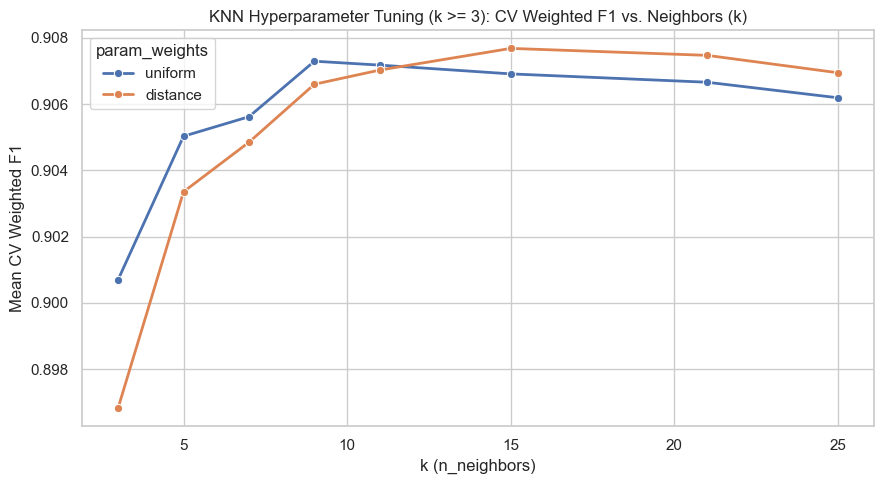

=== K-Nearest Neighbors Performance Metrics ===
Accuracy:            0.9144
Weighted F1 Score:   0.9062
Macro F1 Score:      0.6166
Weighted Precision:  0.9052
Weighted Recall:     0.9144
ROC-AUC (OvR):       0.8926

Classification Report:
              precision    recall  f1-score   support

           F       0.78      0.20      0.32       160
           N       0.94      0.98      0.96     18115
           Q       0.79      0.70      0.74      1607
           S       0.52      0.20      0.29       556
           V       0.81      0.75      0.78      1447

    accuracy                           0.91     21885
   macro avg       0.77      0.56      0.62     21885
weighted avg       0.91      0.91      0.91     21885



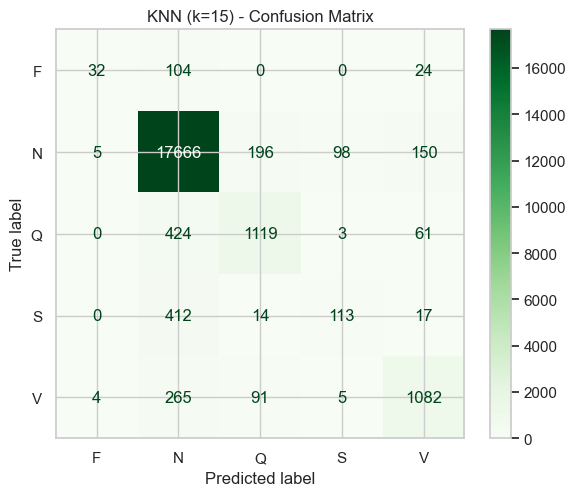

In [7]:
# Hyperparameter Tuning for k >= 3 in KNN
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 25], 'weights': ['uniform', 'distance']}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print(f"Best K-NN Parameters: {grid_knn.best_params_}")
print(f"Best 5-Fold CV Weighted F1: {grid_knn.best_score_:.4f}")

# Plotting CV Score vs k
results_knn = pd.DataFrame(grid_knn.cv_results_)
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=results_knn, x='param_n_neighbors', y='mean_test_score',
    hue='param_weights', marker='o', linewidth=2
)
plt.title("KNN Hyperparameter Tuning (k >= 3): CV Weighted F1 vs. Neighbors (k)")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Weighted F1")
plt.tight_layout()
plt.show()

# Test Evaluation
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
y_proba_knn = best_knn.predict_proba(X_test_scaled)

metrics_knn = evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn, y_proba_knn)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn, display_labels=class_names, cmap='Greens', ax=ax
)
plt.title(f'KNN (k={best_knn.n_neighbors}) - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Algorithm 3: Gaussian Naive Bayes (`var_smoothing` Tuning)

We tune the `var_smoothing` parameter across $[10^{-9}, 10^{-1}]$ to add a portion of the largest feature variance to all feature variances, smoothing probability density estimates and counteracting feature correlation overconfidence:

$$P(Y = c \mid \mathbf{x}) \propto P(Y = c) \prod_{j=1}^p P(x_j \mid Y = c)$$


Best Gaussian NB var_smoothing: 0.1
Best 5-Fold CV Weighted F1: 0.8346
=== Gaussian Naive Bayes Performance Metrics ===
Accuracy:            0.8619
Weighted F1 Score:   0.8324
Macro F1 Score:      0.3790
Weighted Precision:  0.8251
Weighted Recall:     0.8619
ROC-AUC (OvR):       0.8413

Classification Report:
              precision    recall  f1-score   support

           F       0.28      0.04      0.08       160
           N       0.88      0.98      0.93     18115
           Q       0.77      0.29      0.42      1607
           S       0.00      0.00      0.00       556
           V       0.54      0.41      0.47      1447

    accuracy                           0.86     21885
   macro avg       0.49      0.35      0.38     21885
weighted avg       0.83      0.86      0.83     21885



/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

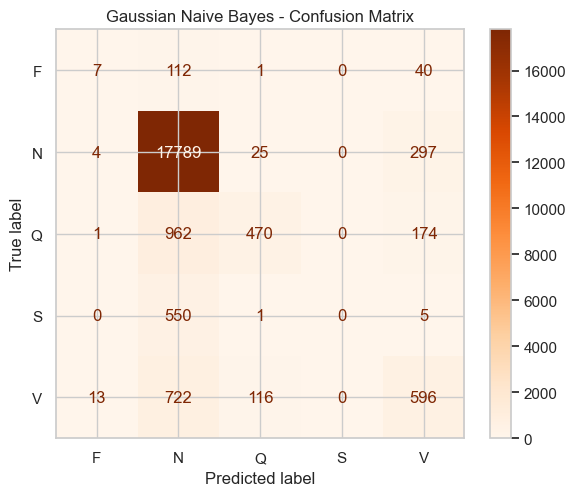

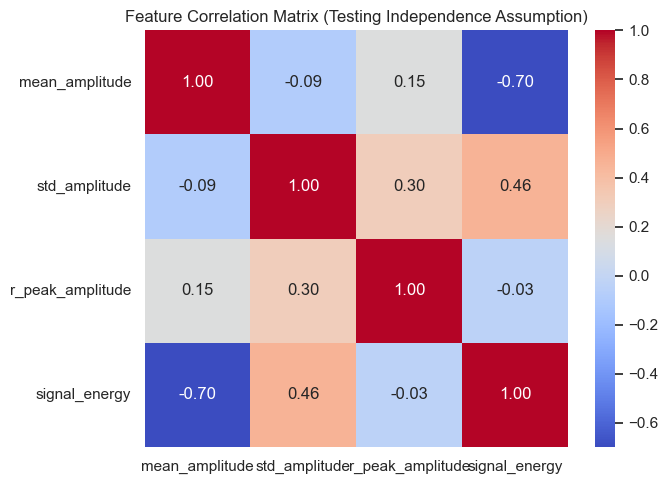

In [8]:
# Tune var_smoothing for Gaussian Naive Bayes
param_grid_gnb = {'var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]}

grid_gnb = GridSearchCV(
    GaussianNB(),
    param_grid_gnb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_gnb.fit(X_train_scaled, y_train)

print(f"Best Gaussian NB var_smoothing: {grid_gnb.best_params_['var_smoothing']}")
print(f"Best 5-Fold CV Weighted F1: {grid_gnb.best_score_:.4f}")

best_gnb = grid_gnb.best_estimator_
y_pred_gnb = best_gnb.predict(X_test_scaled)
y_proba_gnb = best_gnb.predict_proba(X_test_scaled)

metrics_gnb = evaluate_model("Gaussian Naive Bayes", y_test, y_pred_gnb, y_proba_gnb)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnb, display_labels=class_names, cmap='Oranges', ax=ax
)
plt.title('Gaussian Naive Bayes - Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Correlation Matrix Verification
plt.figure(figsize=(7, 5))
sns.heatmap(pd.DataFrame(X_train, columns=feature_names).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix (Testing Independence Assumption)")
plt.tight_layout()
plt.show()

---
## Algorithm 4: Decision Tree Classifier (Restraining Tree Growth)

To eliminate unconstrained leaf memorization, we tune `max_depth` (2 to 6), `min_samples_split` (10, 20, 50), and `min_samples_leaf` (5, 10, 20):

$$\text{Gini}(D) = 1 - \sum_{k=1}^K p_k^2$$

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best 5-Fold CV Weighted F1: 0.8637


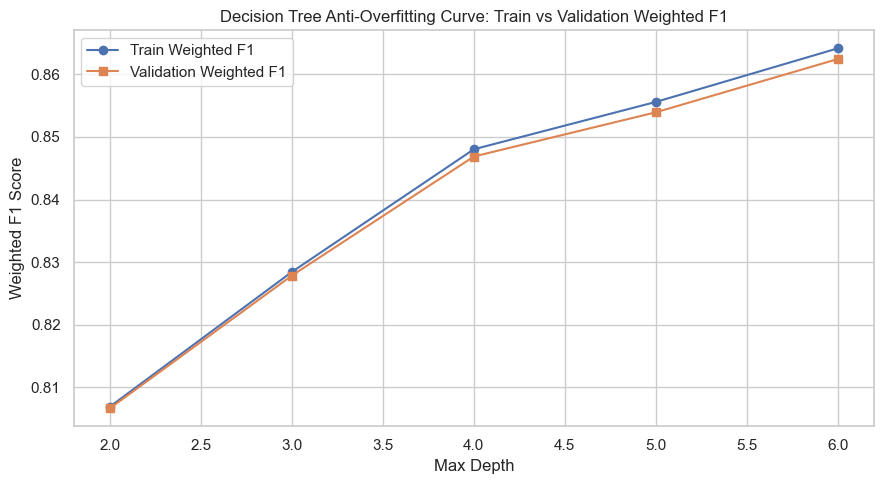

=== Decision Tree Classifier Performance Metrics ===
Accuracy:            0.8868
Weighted F1 Score:   0.8641
Macro F1 Score:      0.4292
Weighted Precision:  0.8516
Weighted Recall:     0.8868
ROC-AUC (OvR):       0.9029

Classification Report:
              precision    recall  f1-score   support

           F       0.00      0.00      0.00       160
           N       0.91      0.98      0.94     18115
           Q       0.76      0.41      0.53      1607
           S       0.00      0.00      0.00       556
           V       0.68      0.66      0.67      1447

    accuracy                           0.89     21885
   macro avg       0.47      0.41      0.43     21885
weighted avg       0.85      0.89      0.86     21885



/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

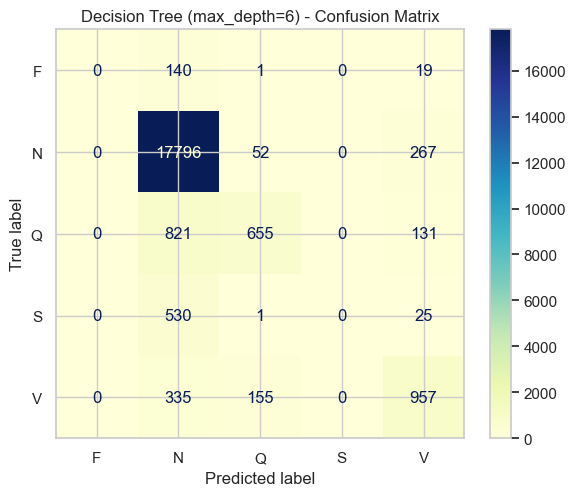

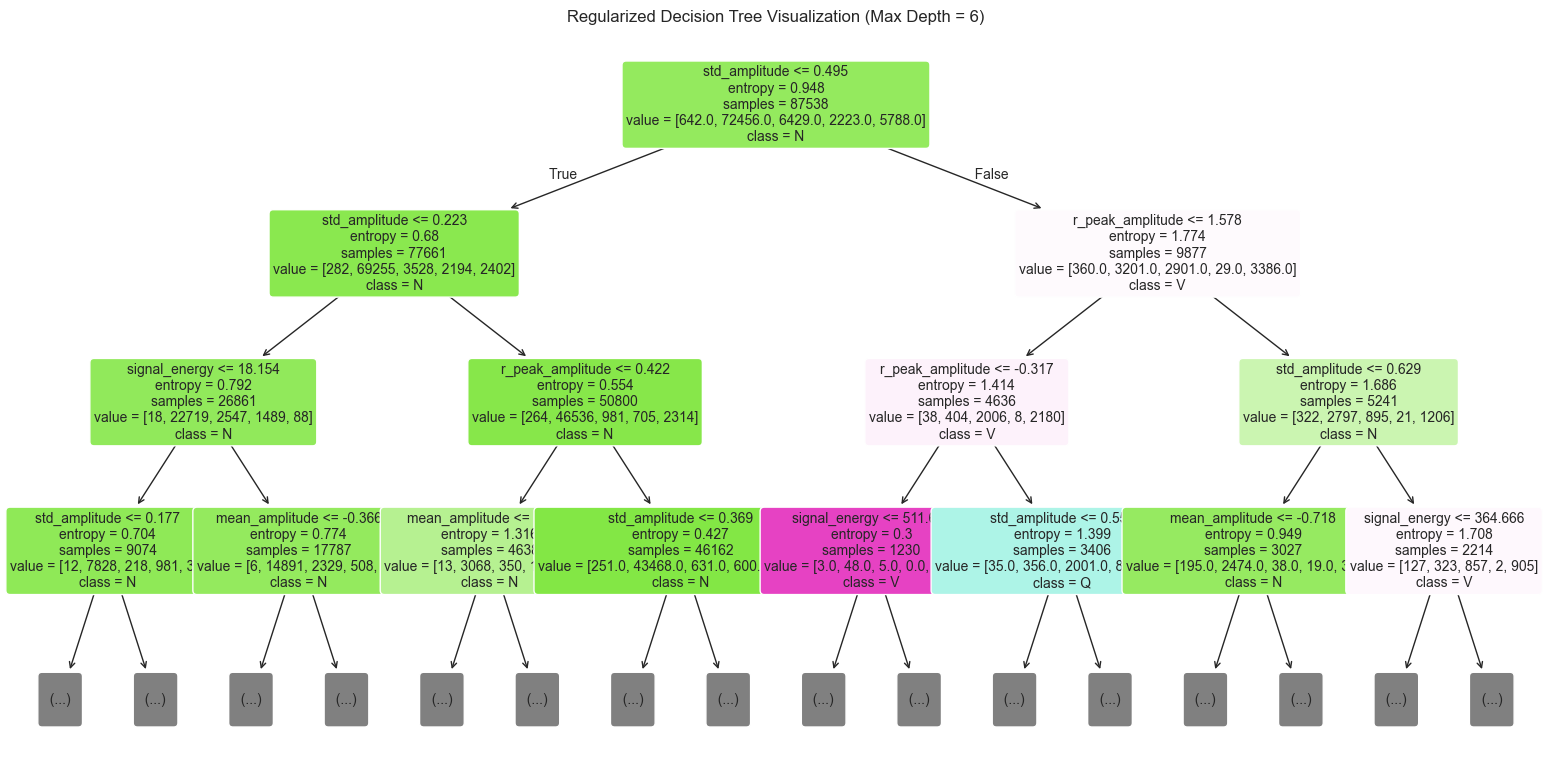

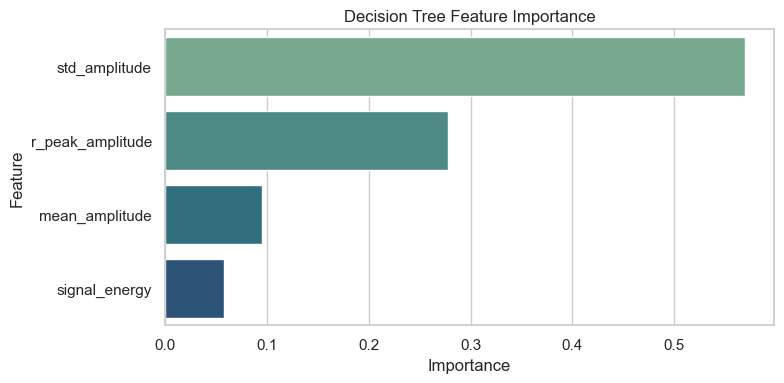

In [9]:
# Regularized Grid Search for Decision Tree
param_grid_dt = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1_weighted',
    return_train_score=True,
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {grid_dt.best_params_}")
print(f"Best 5-Fold CV Weighted F1: {grid_dt.best_score_:.4f}")

# Overfitting Analysis: Train vs Validation Score across max_depth
cv_res = pd.DataFrame(grid_dt.cv_results_)
depth_res = cv_res.groupby('param_max_depth')[['mean_train_score', 'mean_test_score']].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(depth_res['param_max_depth'], depth_res['mean_train_score'], label='Train Weighted F1', marker='o')
plt.plot(depth_res['param_max_depth'], depth_res['mean_test_score'], label='Validation Weighted F1', marker='s')
plt.title("Decision Tree Anti-Overfitting Curve: Train vs Validation Weighted F1")
plt.xlabel("Max Depth")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

# Final Best Regularized Decision Tree Evaluation
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)

metrics_dt = evaluate_model("Decision Tree Classifier", y_test, y_pred_dt, y_proba_dt)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=class_names, cmap='YlGnBu', ax=ax
)
plt.title(f'Decision Tree (max_depth={best_dt.max_depth}) - Confusion Matrix')
plt.tight_layout()
plt.show()

# Tree Structure Visualization
plt.figure(figsize=(16, 8))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title(f"Regularized Decision Tree Visualization (Max Depth = {best_dt.max_depth})")
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure(figsize=(8, 4))
df_fi = pd.DataFrame({'Feature': feature_names, 'Importance': best_dt.feature_importances_}).sort_values('Importance', ascending=False)
sns.barplot(data=df_fi, x='Importance', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

---
## Algorithm 5: Support Vector Machine (SVC - Regularization Tuning)

We tune $C \in \{0.01, 0.1, 1.0, 5.0\}$ and $\gamma \in \{\text{'scale'}, 0.01, 0.1\}$ with cross-validation to balance margin width and prevent over-fitting complex boundaries:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^N \xi_i$$

Best SVC Parameters: {'C': 5.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best 5-Fold CV Weighted F1: 0.8793


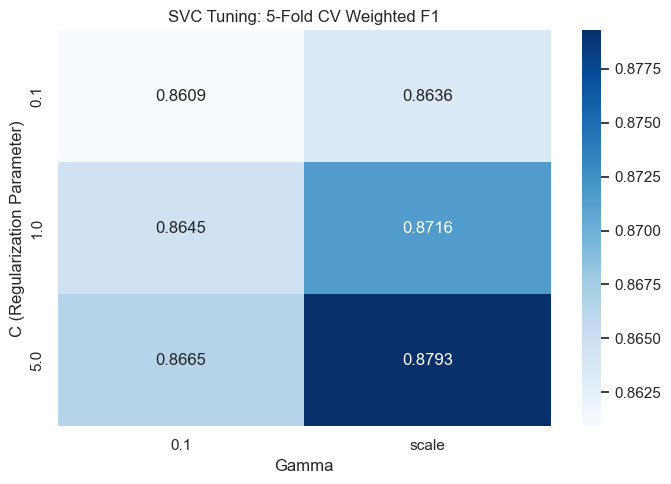

=== Support Vector Machine Performance Metrics ===
Accuracy:            0.8992
Weighted F1 Score:   0.8788
Macro F1 Score:      0.5039
Weighted Precision:  0.8731
Weighted Recall:     0.8992
ROC-AUC (OvR):       0.8360

Classification Report:
              precision    recall  f1-score   support

           F       0.91      0.13      0.23       160
           N       0.91      0.99      0.95     18115
           Q       0.85      0.50      0.63      1607
           S       0.00      0.00      0.00       556
           V       0.79      0.64      0.71      1447

    accuracy                           0.90     21885
   macro avg       0.69      0.45      0.50     21885
weighted avg       0.87      0.90      0.88     21885



/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/anagha_g/ECG-Case-Study/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

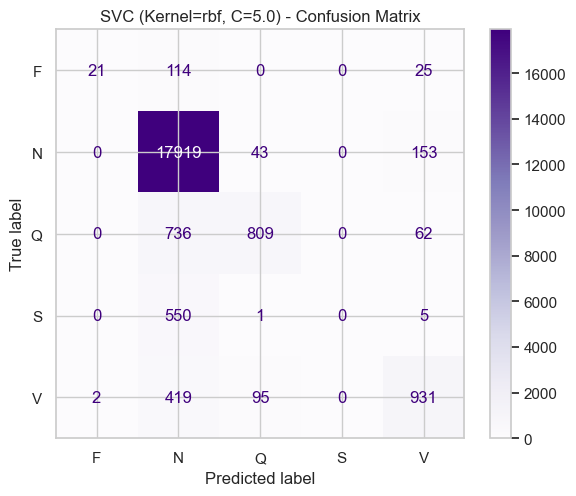

In [11]:
# Hyperparameter Tuning for SVC - Faster Version
param_grid_svc = {
    'C': [0.1, 1.0, 5.0],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.1]
}

grid_svc = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svc,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svc.fit(X_train_scaled, y_train)
print(f"Best SVC Parameters: {grid_svc.best_params_}")
print(f"Best 5-Fold CV Weighted F1: {grid_svc.best_score_:.4f}")

# Heatmap of Tuning Results
svc_results = pd.DataFrame(grid_svc.cv_results_)
pivot_svc = svc_results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score',
    aggfunc='max'
)
plt.figure(figsize=(7, 5))
sns.heatmap(
    pivot_svc,
    annot=True,
    fmt=".4f",
    cmap='Blues'
)
plt.title("SVC Tuning: 5-Fold CV Weighted F1")
plt.xlabel("Gamma")
plt.ylabel("C (Regularization Parameter)")
plt.tight_layout()
plt.show()

# Best SVC Test Evaluation
best_svc = grid_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test_scaled)
# Get prediction probabilities
if hasattr(best_svc, "predict_proba"):
    y_proba_svc = best_svc.predict_proba(X_test_scaled)
else:
    df_scores = best_svc.decision_function(X_test_scaled)
    if df_scores.ndim == 1:
        df_scores = np.column_stack([-df_scores, df_scores])
    exp_scores = np.exp(
        df_scores - np.max(df_scores, axis=1, keepdims=True)
    )
    y_proba_svc = exp_scores / np.sum(
        exp_scores,
        axis=1,
        keepdims=True
    )

# Evaluate Model
metrics_svc = evaluate_model(
    "Support Vector Machine",
    y_test,
    y_pred_svc,
    y_proba_svc
)
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svc,
    display_labels=class_names,
    cmap='Purples',
    ax=ax
)
plt.title(
    f"SVC (Kernel={best_svc.kernel}, C={best_svc.C}) - Confusion Matrix"
)
plt.tight_layout()
plt.show()

---
## Final Regularized Classifier Benchmark & Comparative Analysis

Comparative benchmark summary evaluating all five regularized classification algorithms across Accuracy, Weighted F1 Score, Macro F1 Score, Weighted Precision, Weighted Recall, and multi-class ROC-AUC.

=== Final Regularized Classifier Benchmark Comparison ===
                   Model  Accuracy  Weighted F1  Macro F1  Weighted Precision  Weighted Recall  ROC-AUC (OvR)
     K-Nearest Neighbors  0.914416     0.906195  0.616557            0.905189         0.914416       0.892569
  Support Vector Machine  0.899246     0.878788  0.503884            0.873136         0.899246       0.836013
Decision Tree Classifier  0.886817     0.864081  0.429166            0.851604         0.886817       0.902916
    Gaussian Naive Bayes  0.861869     0.832357  0.379010            0.825078         0.861869       0.841259
     Logistic Regression  0.848024     0.806548  0.294410            0.794012         0.848024       0.828977


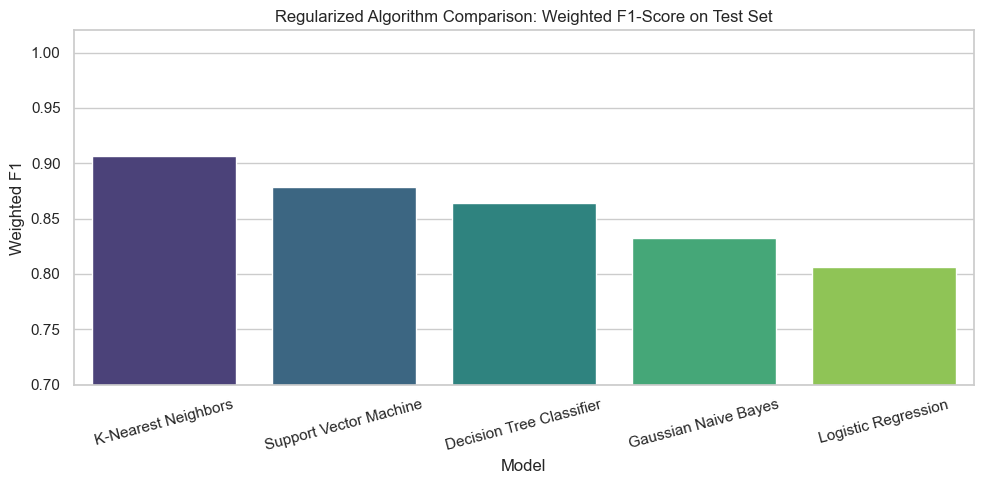

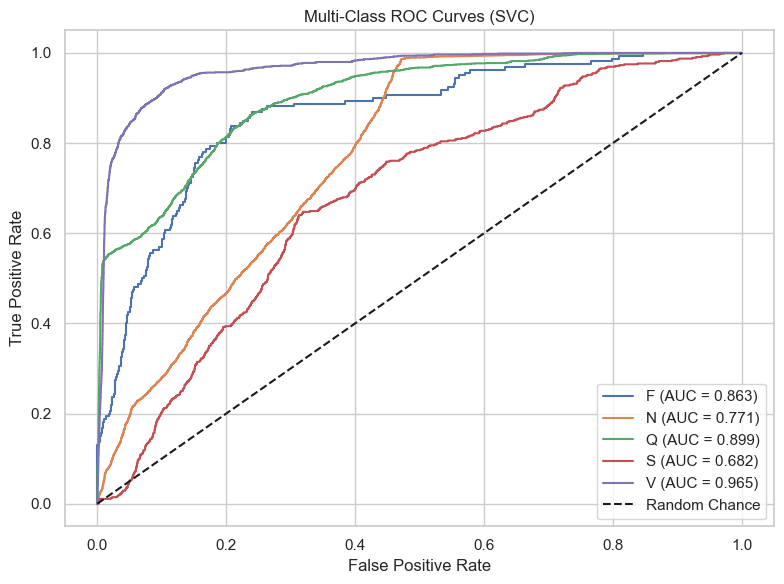

In [12]:
# Compile Evaluation Comparison Table
comparison_df = pd.DataFrame([
    metrics_lr,
    metrics_knn,
    metrics_gnb,
    metrics_dt,
    metrics_svc
]).sort_values(by='Weighted F1', ascending=False)

print("=== Final Regularized Classifier Benchmark Comparison ===")
print(comparison_df.to_string(index=False))

# Visual Comparison of Models
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Model', y='Weighted F1', hue='Model', palette='viridis', legend=False)
plt.title("Regularized Algorithm Comparison: Weighted F1-Score on Test Set")
plt.ylim(0.7, 1.02)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Multi-class ROC Curves Comparison
plt.figure(figsize=(8, 6))
for i, c_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba_svc[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{c_name} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-Class ROC Curves ({best_svc.__class__.__name__})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()